In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", None)

In [2]:
BASE_DIR = Path("..")

RAW_DATA_DIR = BASE_DIR / "data" / "raw"
PROCESSED_DATA_DIR = BASE_DIR / "data" / "processed"

old_data_path = RAW_DATA_DIR / "sensor.csv"

PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
df = pd.read_csv(old_data_path)

print(f"Dataset shape: {df.shape}")

df.head()

Dataset shape: (220320, 55)


,Unnamed: 0,timestamp,sensor_00,sensor_01,sensor_02,sensor_03,sensor_04,sensor_05,sensor_06,sensor_07,sensor_08,sensor_09,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,sensor_22,sensor_23,sensor_24,sensor_25,sensor_26,sensor_27,sensor_28,sensor_29,sensor_30,sensor_31,sensor_32,sensor_33,sensor_34,sensor_35,sensor_36,sensor_37,sensor_38,sensor_39,sensor_40,sensor_41,sensor_42,sensor_43,sensor_44,sensor_45,sensor_46,sensor_47,sensor_48,sensor_49,sensor_50,sensor_51,machine_status
0,0,2018-04-01 00:00:00,2.465394,47.09201,53.2118,46.310760,634.3750,76.45975,13.41146,16.13136,15.56713,15.05353,37.22740,47.52422,31.11716,1.681353,419.5747,NaN,461.8781,466.3284,2.565284,665.3993,398.9862,880.0001,498.8926,975.9409,627.6740,741.7151,848.0708,429.0377,785.1935,684.9443,594.4445,682.8125,680.4416,433.7037,171.9375,341.9039,195.0655,90.32386,40.36458,31.51042,70.57291,30.98958,31.770832,41.92708,39.641200,65.68287,50.92593,38.194440,157.9861,67.70834,243.0556,201.3889,NORMAL
1,1,2018-04-01 00:01:00,2.465394,47.09201,53.2118,46.310760,634.3750,76.45975,13.41146,16.13136,15.56713,15.05353,37.22740,47.52422,31.11716,1.681353,419.5747,NaN,461.8781,466.3284,2.565284,665.3993,398.9862,880.0001,498.8926,975.9409,627.6740,741.7151,848.0708,429.0377,785.1935,684.9443,594.4445,682.8125,680.4416,433.7037,171.9375,341.9039,195.0655,90.32386,40.36458,31.51042,70.57291,30.98958,31.770832,41.92708,39.641200,65.68287,50.92593,38.194440,157.9861,67.70834,243.0556,201.3889,NORMAL
2,2,2018-04-01 00:02:00,2.444734,47.35243,53.2118,46.397570,638.8889,73.54598,13.32465,16.03733,15.61777,15.01013,37.86777,48.17723,32.08894,1.708474,420.8480,NaN,462.7798,459.6364,2.500062,666.2234,399.9418,880.4237,501.3617,982.7342,631.1326,740.8031,849.8997,454.2390,778.5734,715.6266,661.5740,721.8750,694.7721,441.2635,169.9820,343.1955,200.9694,93.90508,41.40625,31.25000,69.53125,30.46875,31.770830,41.66666,39.351852,65.39352,51.21528,38.194443,155.9606,67.12963,241.3194,203.7037,NORMAL
3,3,2018-04-01 00:03:00,2.460474,47.09201,53.1684,46.397568,628.1250,76.98898,13.31742,16.24711,15.69734,15.08247,38.57977,48.65607,31.67221,1.579427,420.7494,NaN,462.8980,460.8858,2.509521,666.0114,399.1046,878.8917,499.0430,977.7520,625.4076,739.2722,847.7579,474.8731,779.5091,690.4011,686.1111,754.6875,683.3831,446.2493,166.4987,343.9586,193.1689,101.04060,41.92708,31.51042,72.13541,30.46875,31.510420,40.88541,39.062500,64.81481,51.21528,38.194440,155.9606,66.84028,240.4514,203.1250,NORMAL
4,4,2018-04-01 00:04:00,2.445718,47.13541,53.2118,46.397568,636.4583,76.58897,13.35359,16.21094,15.69734,15.08247,39.48939,49.06298,31.95202,1.683831,419.8926,NaN,461.4906,468.2206,2.604785,663.2111,400.5426,882.5874,498.5383,979.5755,627.1830,737.6033,846.9182,408.8159,785.2307,704.6937,631.4814,766.1458,702.4431,433.9081,164.7498,339.9630,193.8770,101.70380,42.70833,31.51042,76.82291,30.98958,31.510420,41.40625,38.773150,65.10416,51.79398,38.773150,158.2755,66.55093,242.1875,201.3889,NORMAL


In [4]:
df_clean = df.copy()

In [5]:
df_clean["timestamp"] = pd.to_datetime(
    df_clean["timestamp"],
    errors="coerce"
)

In [6]:
print(df_clean["timestamp"].isnull().sum())

0


In [7]:
df_clean = df_clean.sort_values(
    "timestamp"
).reset_index(drop=True)

In [8]:
print(
    "Duplicate rows:",
    df_clean.duplicated().sum()
)

Duplicate rows: 0


In [9]:
df_clean = df_clean.drop_duplicates().reset_index(drop=True)

In [10]:
sensor_columns = [
    col for col in df_clean.columns
    if col.startswith("sensor_")
]

print(f"Number of sensors: {len(sensor_columns)}")
print(sensor_columns)

Number of sensors: 52
['sensor_00', 'sensor_01', 'sensor_02', 'sensor_03', 'sensor_04', 'sensor_05', 'sensor_06', 'sensor_07', 'sensor_08', 'sensor_09', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21', 'sensor_22', 'sensor_23', 'sensor_24', 'sensor_25', 'sensor_26', 'sensor_27', 'sensor_28', 'sensor_29', 'sensor_30', 'sensor_31', 'sensor_32', 'sensor_33', 'sensor_34', 'sensor_35', 'sensor_36', 'sensor_37', 'sensor_38', 'sensor_39', 'sensor_40', 'sensor_41', 'sensor_42', 'sensor_43', 'sensor_44', 'sensor_45', 'sensor_46', 'sensor_47', 'sensor_48', 'sensor_49', 'sensor_50', 'sensor_51']


In [11]:
missing_report = pd.DataFrame({
    "missing_count": df_clean[sensor_columns].isnull().sum(),
    "missing_percentage": (
        df_clean[sensor_columns].isnull().mean() * 100
    ),
    "unique_values": df_clean[sensor_columns].nunique(),
    "mean": df_clean[sensor_columns].mean(),
    "std": df_clean[sensor_columns].std()
})

missing_report = missing_report.sort_values(
    "missing_percentage",
    ascending=False
)

missing_report

,missing_count,missing_percentage,unique_values,mean,std
sensor_15,220320,100.000000,0,NaN,NaN
sensor_50,77017,34.956881,1135,183.049260,65.258650
sensor_51,15383,6.982117,1108,202.699667,109.588607
sensor_00,10208,4.633261,1253,2.372221,0.412227
sensor_07,5451,2.474129,531,15.843152,2.201155
sensor_08,5107,2.317992,626,15.200721,2.037390
sensor_06,4798,2.177741,812,13.501537,2.163736
sensor_09,4595,2.085603,565,14.799210,2.091963
sensor_01,369,0.167484,831,47.591611,3.296666
sensor_30,261,0.118464,2070,614.596442,195.726872


In [12]:
high_missing_sensors = ["sensor_50", "sensor_51"]

for sensor in high_missing_sensors:
    print(f"\n===== {sensor} =====")
    
    missing_mask = df_clean[sensor].isna()
    
    print("Missing count:", missing_mask.sum())
    print("First missing timestamp:",
          df_clean.loc[missing_mask, "timestamp"].min())
    print("Last missing timestamp:",
          df_clean.loc[missing_mask, "timestamp"].max())


===== sensor_50 =====
Missing count: 77017
First missing timestamp: 2018-04-18 10:32:00
Last missing timestamp: 2018-08-31 23:59:00

===== sensor_51 =====
Missing count: 15383
First missing timestamp: 2018-04-18 10:32:00
Last missing timestamp: 2018-08-31 18:50:00


In [13]:
def get_missing_periods(df, sensor):
    mask = df[sensor].isna()
    
    groups = (mask != mask.shift()).cumsum()
    
    periods = (
        df[mask]
        .groupby(groups[mask])
        .agg(
            start=("timestamp", "min"),
            end=("timestamp", "max"),
            count=("timestamp", "size")
        )
        .sort_values("count", ascending=False)
    )
    
    return periods

In [14]:
for sensor in ["sensor_50", "sensor_51"]:
    print(f"\n===== {sensor} =====")
    display(get_missing_periods(df_clean, sensor).head(10))


===== sensor_50 =====


,start,end,count
sensor_50,,,
16,2018-07-09 12:44:00,2018-08-31 23:59:00,76996
4,2018-04-27 17:48:00,2018-04-27 17:55:00,8
6,2018-05-31 23:52:00,2018-05-31 23:59:00,8
2,2018-04-18 10:32:00,2018-04-18 10:32:00,1
8,2018-07-03 15:35:00,2018-07-03 15:35:00,1
10,2018-07-03 15:53:00,2018-07-03 15:53:00,1
12,2018-07-04 13:57:00,2018-07-04 13:57:00,1
14,2018-07-04 15:05:00,2018-07-04 15:05:00,1



===== sensor_51 =====


,start,end,count
sensor_51,,,
8,2018-06-20 07:58:00,2018-06-30 23:53:00,15356
4,2018-04-27 17:48:00,2018-04-27 17:55:00,8
6,2018-05-31 23:52:00,2018-05-31 23:59:00,8
18,2018-07-11 09:12:00,2018-07-11 09:14:00,3
20,2018-08-31 18:48:00,2018-08-31 18:50:00,3
2,2018-04-18 10:32:00,2018-04-18 10:32:00,1
12,2018-07-03 15:53:00,2018-07-03 15:53:00,1
10,2018-07-03 15:35:00,2018-07-03 15:35:00,1
16,2018-07-04 15:05:00,2018-07-04 15:05:00,1


In [15]:
duplicate_timestamps = df_clean["timestamp"].duplicated().sum()

print("Duplicate timestamps:", duplicate_timestamps)

Duplicate timestamps: 0


In [16]:
time_diff = df_clean["timestamp"].diff()

print(time_diff.describe())

count             220319
mean     0 days 00:01:00
std      0 days 00:00:00
min      0 days 00:01:00
25%      0 days 00:01:00
50%      0 days 00:01:00
75%      0 days 00:01:00
max      0 days 00:01:00
Name: timestamp, dtype: object


In [17]:
large_gaps = time_diff[time_diff > pd.Timedelta(minutes=1)]

print("Number of gaps > 1 minute:", len(large_gaps))

Number of gaps > 1 minute: 0


In [18]:
print("Largest time gaps:")

display(
    time_diff
    .sort_values(ascending=False)
    .head(20)
)

Largest time gaps:


1        0 days 00:01:00
146872   0 days 00:01:00
146874   0 days 00:01:00
146875   0 days 00:01:00
146876   0 days 00:01:00
146877   0 days 00:01:00
146878   0 days 00:01:00
146879   0 days 00:01:00
146880   0 days 00:01:00
146881   0 days 00:01:00
146882   0 days 00:01:00
146883   0 days 00:01:00
146884   0 days 00:01:00
146885   0 days 00:01:00
146886   0 days 00:01:00
146887   0 days 00:01:00
146888   0 days 00:01:00
146889   0 days 00:01:00
146890   0 days 00:01:00
146891   0 days 00:01:00
Name: timestamp, dtype: timedelta64[ns]

In [19]:
missing_summary = (
    df_clean[sensor_columns]
    .isna()
    .mean()
    .sort_values(ascending=False)
)

missing_summary

sensor_15    1.000000
sensor_50    0.349569
sensor_51    0.069821
sensor_00    0.046333
sensor_07    0.024741
sensor_08    0.023180
sensor_06    0.021777
sensor_09    0.020856
sensor_01    0.001675
sensor_30    0.001185
sensor_29    0.000327
sensor_32    0.000309
sensor_18    0.000209
sensor_17    0.000209
sensor_22    0.000186
sensor_25    0.000163
sensor_16    0.000141
sensor_44    0.000123
sensor_41    0.000123
sensor_40    0.000123
sensor_49    0.000123
sensor_48    0.000123
sensor_45    0.000123
sensor_42    0.000123
sensor_38    0.000123
sensor_39    0.000123
sensor_46    0.000123
sensor_47    0.000123
sensor_43    0.000123
sensor_14    0.000095
sensor_26    0.000091
sensor_02    0.000086
sensor_04    0.000086
sensor_05    0.000086
sensor_10    0.000086
sensor_03    0.000086
sensor_13    0.000086
sensor_12    0.000086
sensor_11    0.000086
sensor_19    0.000073
sensor_35    0.000073
sensor_34    0.000073
sensor_24    0.000073
sensor_27    0.000073
sensor_20    0.000073
sensor_23 

In [20]:
print("Sensors with more than 5% missing:")

display(
    missing_summary[missing_summary > 0.05]
)

Sensors with more than 5% missing:


sensor_15    1.000000
sensor_50    0.349569
sensor_51    0.069821
dtype: float64

In [21]:
df_clean = df_clean.drop(columns=["sensor_15"])

sensor_columns = [
    col for col in sensor_columns
    if col != "sensor_15"
]

print("Remaining sensor columns:", len(sensor_columns))

Remaining sensor columns: 51


In [22]:
print("sensor_15" in df_clean.columns)

False


In [23]:
sensor = "sensor_50"

missing_status = (
    df_clean.loc[df_clean[sensor].isna(), "machine_status"]
    .value_counts(dropna=False)
)

print(missing_status)

machine_status
NORMAL        76936
RECOVERING       80
BROKEN            1
Name: count, dtype: int64


In [24]:
sensor = "sensor_51"

missing_status = (
    df_clean.loc[df_clean[sensor].isna(), "machine_status"]
    .value_counts(dropna=False)
)

print(missing_status)

machine_status
NORMAL        12384
RECOVERING     2998
BROKEN            1
Name: count, dtype: int64


In [25]:
for sensor in sensor_columns:
    if df_clean[sensor].isna().any():
        df_clean[f"{sensor}_missing"] = (
            df_clean[sensor].isna().astype(int)
        )

In [26]:
missing_indicator_columns = [
    col for col in df_clean.columns
    if col.endswith("_missing")
]

print("Missing indicators:", len(missing_indicator_columns))
print(missing_indicator_columns)

Missing indicators: 51
['sensor_00_missing', 'sensor_01_missing', 'sensor_02_missing', 'sensor_03_missing', 'sensor_04_missing', 'sensor_05_missing', 'sensor_06_missing', 'sensor_07_missing', 'sensor_08_missing', 'sensor_09_missing', 'sensor_10_missing', 'sensor_11_missing', 'sensor_12_missing', 'sensor_13_missing', 'sensor_14_missing', 'sensor_16_missing', 'sensor_17_missing', 'sensor_18_missing', 'sensor_19_missing', 'sensor_20_missing', 'sensor_21_missing', 'sensor_22_missing', 'sensor_23_missing', 'sensor_24_missing', 'sensor_25_missing', 'sensor_26_missing', 'sensor_27_missing', 'sensor_28_missing', 'sensor_29_missing', 'sensor_30_missing', 'sensor_31_missing', 'sensor_32_missing', 'sensor_33_missing', 'sensor_34_missing', 'sensor_35_missing', 'sensor_36_missing', 'sensor_37_missing', 'sensor_38_missing', 'sensor_39_missing', 'sensor_40_missing', 'sensor_41_missing', 'sensor_42_missing', 'sensor_43_missing', 'sensor_44_missing', 'sensor_45_missing', 'sensor_46_missing', 'sensor_47

In [27]:
for sensor in ["sensor_50", "sensor_51"]:
    
    print(f"\n===== {sensor} =====")
    
    print("Available values:")
    print(df_clean[sensor].describe())


===== sensor_50 =====
Available values:
count    143303.000000
mean        183.049260
std          65.258650
min          27.488426
25%         167.534700
50%         193.865700
75%         219.907400
max        1000.000000
Name: sensor_50, dtype: float64

===== sensor_51 =====
Available values:
count    204937.000000
mean        202.699667
std         109.588607
min          27.777779
25%         179.108800
50%         197.338000
75%         216.724500
max        1000.000000
Name: sensor_51, dtype: float64


In [28]:
for sensor in ["sensor_50", "sensor_51"]:
    
    total = len(df_clean)
    available = df_clean[sensor].notna().sum()
    missing = df_clean[sensor].isna().sum()
    
    print(f"\n===== {sensor} =====")
    print("Total:", total)
    print("Available:", available)
    print("Missing:", missing)
    print("Available %:", round(available / total * 100, 2))


===== sensor_50 =====
Total: 220320
Available: 143303
Missing: 77017
Available %: 65.04

===== sensor_51 =====
Total: 220320
Available: 204937
Missing: 15383
Available %: 93.02


In [29]:
for sensor in ["sensor_50", "sensor_51"]:
    
    print(f"\n===== {sensor} =====")
    
    display(
        df_clean
        .groupby("machine_status")[sensor]
        .agg(["count", "mean", "std", "min", "max"])
    )


===== sensor_50 =====


,count,mean,std,min,max
machine_status,,,,,
BROKEN,6,211.757318,119.274664,32.407406,401.9097
NORMAL,128900,199.021829,45.394732,30.960650,1000.0000
RECOVERING,14397,40.030832,34.583243,27.488426,483.5069



===== sensor_51 =====


,count,mean,std,min,max
machine_status,,,,,
BROKEN,6,235.628850,57.796449,174.768500,324.6528
NORMAL,193452,200.720874,62.304341,30.960648,1000.0000
RECOVERING,11479,236.030423,384.480131,27.777779,1000.0000


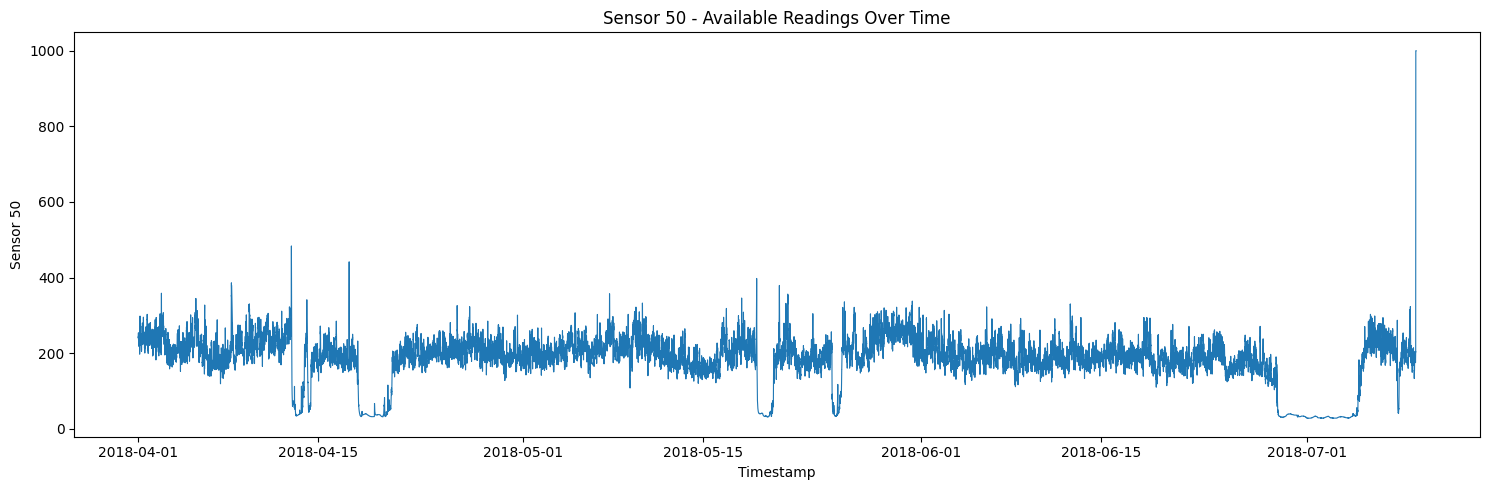

In [30]:
plt.figure(figsize=(15, 5))

plt.plot(
    df_clean["timestamp"],
    df_clean["sensor_50"],
    linewidth=0.8
)

plt.title("Sensor 50 - Available Readings Over Time")
plt.xlabel("Timestamp")
plt.ylabel("Sensor 50")
plt.tight_layout()
plt.show()

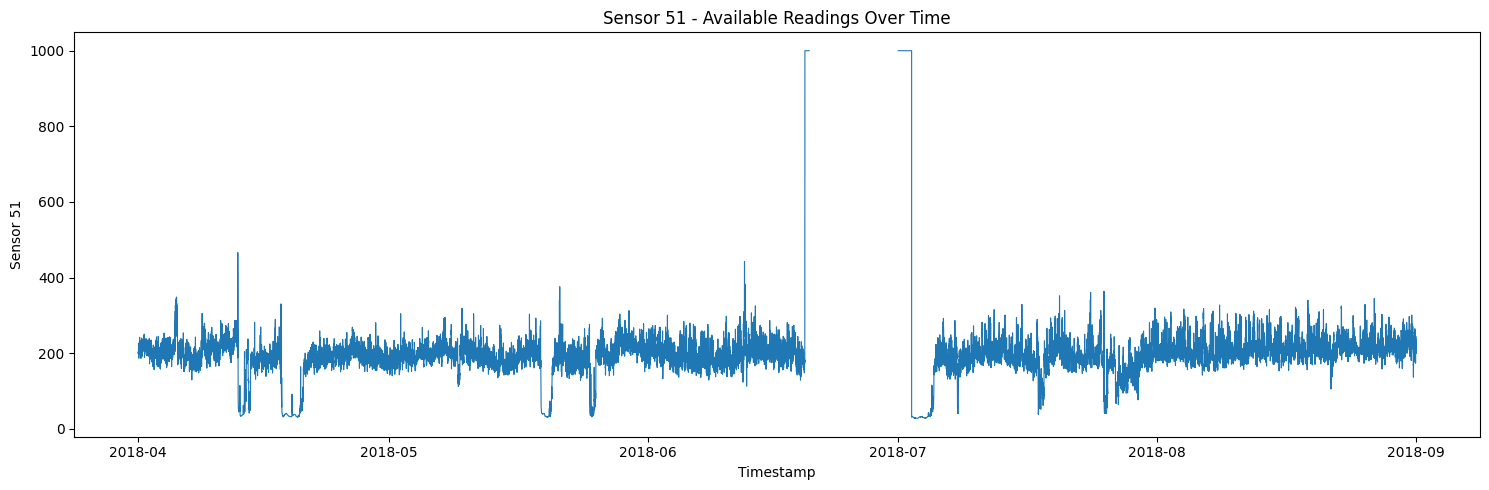

In [31]:
plt.figure(figsize=(15, 5))

plt.plot(
    df_clean["timestamp"],
    df_clean["sensor_51"],
    linewidth=0.8
)

plt.title("Sensor 51 - Available Readings Over Time")
plt.xlabel("Timestamp")
plt.ylabel("Sensor 51")
plt.tight_layout()
plt.show()

In [32]:
for sensor in ["sensor_50", "sensor_51"]:
    print(f"\n===== {sensor} =====")

    status_missing = (
        df_clean
        .groupby("machine_status")[sensor]
        .apply(lambda x: x.isna().mean() * 100)
        .round(3)
        .rename("missing_percentage")
    )

    display(status_missing)


===== sensor_50 =====


machine_status
BROKEN        14.286
NORMAL        37.377
RECOVERING     0.553
Name: missing_percentage, dtype: float64


===== sensor_51 =====


machine_status
BROKEN        14.286
NORMAL         6.016
RECOVERING    20.709
Name: missing_percentage, dtype: float64

In [33]:
df_model = df_clean.copy()
df_model = df_model.set_index("timestamp")

short_gap_sensors = [
    sensor
    for sensor in sensor_columns
    if sensor not in ["sensor_50", "sensor_51"]
]

for sensor in short_gap_sensors:
    df_model[sensor] = (
        df_model[sensor]
        .interpolate(
            method="time",
            limit=60,
            limit_direction="both"
        )
    )

In [34]:
df_model = df_model.reset_index()

df_model = df_model.drop(
    columns=["Unnamed: 0"],
    errors="ignore"
)

assert len(df_model) == len(df_clean)
assert df_model["timestamp"].notna().all()
assert df_model["timestamp"].is_monotonic_increasing
assert not df_model["timestamp"].duplicated().any()
assert "sensor_15" not in df_model.columns
assert "Unnamed: 0" not in df_model.columns

assert (
    df_model["timestamp"].diff().dropna()
    == pd.Timedelta(minutes=1)
).all()

numeric_sensor_columns = [
    sensor
    for sensor in sensor_columns
    if sensor in df_model.columns
]

assert not df_model[numeric_sensor_columns].isin(
    [np.inf, -np.inf]
).any().any()

print("Final validation passed.")
print("Shape:", df_model.shape)

Final validation passed.
Shape: (220320, 104)


In [35]:
remaining_missing = (
    df_model[sensor_columns]
    .isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .round(3)
)

display(remaining_missing[remaining_missing > 0])

sensor_50    34.957
sensor_51     6.982
sensor_00     4.419
sensor_07     2.301
sensor_08     2.146
sensor_06     1.986
sensor_09     1.937
sensor_30     0.054
sensor_01     0.036
dtype: float64

In [36]:
model_path = PROCESSED_DATA_DIR / "sensor_clean_model.csv"

df_model.to_csv(
    model_path,
    index=False
)

print(f"Saved model dataset to: {model_path}")

Saved model dataset to: ..\data\processed\sensor_clean_model.csv
